## Parse disk detector output

In [132]:
# Cell 1: Shared configuration + parse PHITS disk-detector outputs for proton and deuteron
import os
import re
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Shared constants used across notebook cells
ANALYSIS_CONFIG = {
    'TARGET_Z_CM': 3.95,
    'DETECTOR_RADIUS_CM': 65.0,
    'ANGLE_BIN_DEG': 10,
    'N_DISKS': 36,
    'DEFAULT_NE': 50,
    'XTICKS_DEG': np.arange(-180, 181, 30),
    'SHOTS_PER_DATASET': {
        'proton': 1e10,
        'deuteron': 1e10,
    },
    'PARTICLE_SYMBOL': {
        'proton': 'p',
        'deuteron': 'd',
    },
    'PARTICLE_COLORS': {
        'proton': 'royalblue',
        'deuteron': 'firebrick',
    },
    # Requested beam-pointing angles for angular-band overlays
    'BEAM_POINTING_DEG': {
        'proton': -3.3,
        'deuteron': -12.1,
    },
    'BEAM_FWHM_DEG': {
        'proton': 12.4,
        'deuteron': 11.7,
    },
    'BE_TARGET_SHADOW_DEG': (-18.0, 18.0),
    'DATASET_PATHS': {
        'proton': '../output_proton/neutron_disk_spectra.out',
        'deuteron': '../output_deuteron/neutron_disk_spectra.out',
    },
    'JENDL_CANDIDATES': {
        'proton': [
            'jendl_pro_Be9.txt',
            os.path.join('analysis', 'jendl_pro_Be9.txt'),
            '../analysis/jendl_pro_Be9.txt',
        ],
        'deuteron': [
            'jendl_deu_Be9.txt',
            os.path.join('analysis', 'jendl_deu_Be9.txt'),
            '../analysis/jendl_deu_Be9.txt',
        ],
    },
    'XS_MAX_ENERGY_MEV': 100.0,
}

# Geometry constants reused by the dedicated top-down geometry cell
GEOMETRY_CONFIG = {
    'CYLINDER': {
        'center_x_cm': 0.0,
        'center_z_cm': 3.95,
        'r_inner_cm': 63.1825,
        'r_outer_cm': 63.8175,
    },
    'BE_TARGET': {
        'z_min_cm': 3.90,
        'z_max_cm': 4.00,
        'r_inner_cm': 0.079375,
        'r_outer_cm': 1.27,
    },
    'DETECTORS': {
        'radius_cm': 65.0,
        'dr_cm': 0.2,
        'width_tangential_cm': 1.9,
    },
    # PHITS source-tilt values used for top-down beam direction illustration
    'BEAM_TILT_TOPDOWN_DEG': {
        'proton': 3.3,
        'deuteron': 12.1,
    },
    'BEAM_DRAW_LEN_CM': 82.0,
}

# Disk center angles (must match PHITS input: -175, -165, ..., +175)
phi_centers = np.arange(-175, 180, ANALYSIS_CONFIG['ANGLE_BIN_DEG'], dtype=float)
assert len(phi_centers) == ANALYSIS_CONFIG['N_DISKS']


def first_existing(candidates):
    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate
    return None


def parse_disk_ttrack(path):
    """Parse T-Track mesh=reg output (axis=eng, 36 regions)."""
    with open(path) as fh:
        raw = fh.read()

    m_ne = re.search(r"^\s*#?\s*ne\s*=\s*(\d+)", raw, re.MULTILINE)
    ne = int(m_ne.group(1)) if m_ne else ANALYSIS_CONFIG['DEFAULT_NE']

    m_emin = re.search(r"^\s*#?\s*emin\s*=\s*([0-9eE.+\-]+)", raw, re.MULTILINE)
    m_emax = re.search(r"^\s*#?\s*emax\s*=\s*([0-9eE.+\-]+)", raw, re.MULTILINE)
    emin = float(m_emin.group(1)) if m_emin else 1e-10
    emax = float(m_emax.group(1)) if m_emax else 20.0

    e_edges = np.logspace(np.log10(emin), np.log10(emax), ne + 1)

    numeric_pattern = re.compile(
        r"^\s*([0-9][0-9eE.+\-]*)\s+([0-9][0-9eE.+\-]*)\s+([0-9eE.+\-]+)\s+([0-9eE.+\-]+)\s*$",
        re.MULTILINE,
    )
    rows = []
    for match in numeric_pattern.finditer(raw):
        flux_val = float(match.group(3))
        err_val = float(match.group(4))
        rows.append((flux_val, err_val))

    total_expected = ANALYSIS_CONFIG['N_DISKS'] * ne
    print(f"  ne={ne}, emin={emin:.1e}, emax={emax:.1e}")
    print(f"  Expected {total_expected} data rows, found {len(rows)}")

    if len(rows) < total_expected:
        raise RuntimeError(
            f"Found {len(rows)} data rows but expected {total_expected} "
            f"({ANALYSIS_CONFIG['N_DISKS']} regions x {ne} energy bins). "
            "Check that PHITS ran to completion."
        )

    arr = np.array(rows[:total_expected], dtype=float)
    arr = arr.reshape((ANALYSIS_CONFIG['N_DISKS'], ne, 2))
    flux = arr[:, :, 0]
    rel_err = arr[:, :, 1]

    return e_edges, flux, rel_err


# Load proton + deuteron datasets from fixed paths
warnings.filterwarnings('ignore', category=RuntimeWarning)

print(f"cwd: {os.getcwd()}")
DATASETS = {}

for particle, out_file in ANALYSIS_CONFIG['DATASET_PATHS'].items():
    out_dir = os.path.dirname(out_file)

    if not os.path.isfile(out_file):
        raise FileNotFoundError(f"[{particle}] Required dataset file not found: {out_file}")

    print(f"\n[{particle}] output file: {out_file}")
    print(f"[{particle}] parsing disk detector output ...")
    e_edges, flux2d, relerr2d = parse_disk_ttrack(out_file)

    ec = np.sqrt(e_edges[:-1] * e_edges[1:])
    spectra = flux2d * ANALYSIS_CONFIG['DETECTOR_RADIUS_CM']**2
    errors = flux2d * relerr2d * ANALYSIS_CONFIG['DETECTOR_RADIUS_CM']**2
    de = np.diff(e_edges)
    total_per_disk = (spectra * de[np.newaxis, :]).sum(axis=1)

    print(f"[{particle}] spectra shape: {spectra.shape} ({ANALYSIS_CONFIG['N_DISKS']} disks x {len(ec)} bins)")
    print(f"[{particle}] phi centres: {phi_centers[0]:.0f} deg to {phi_centers[-1]:.0f} deg")
    print(f"[{particle}] energy range: {ec[0]:.2e} to {ec[-1]:.2e} MeV")
    print(f"[{particle}] total yield (all disks): {total_per_disk.sum() * np.radians(ANALYSIS_CONFIG['ANGLE_BIN_DEG']):.3e} n/source")

    DATASETS[particle] = {
        'OUT_FILE': out_file,
        'OUT_DIR': out_dir,
        'E_EDGES': e_edges,
        'NE': len(ec),
        'ec': ec,
        'flux2d': flux2d,
        'relerr2d': relerr2d,
        'spectra': spectra,
        'errors': errors,
        'total_per_disk': total_per_disk,
    }




cwd: /Users/matthewricks/Library/CloudStorage/OneDrive-Stanford/Research Projects/Neutron Converter/NeutronConverter_PHITS/analysis

[proton] output file: ../output_proton/neutron_disk_spectra.out
[proton] parsing disk detector output ...
  ne=50, emin=1.0e-10, emax=1.2e+01
  Expected 1800 data rows, found 1800
[proton] spectra shape: (36, 50) (36 disks x 50 bins)
[proton] phi centres: -175 deg to 175 deg
[proton] energy range: 1.29e-10 to 9.30e+00 MeV
[proton] total yield (all disks): 2.203e-05 n/source

[deuteron] output file: ../output_deuteron/neutron_disk_spectra.out
[deuteron] parsing disk detector output ...
  ne=50, emin=1.0e-10, emax=1.2e+01
  Expected 1800 data rows, found 1800
[deuteron] spectra shape: (36, 50) (36 disks x 50 bins)
[deuteron] phi centres: -175 deg to 175 deg
[deuteron] energy range: 1.29e-10 to 9.30e+00 MeV
[deuteron] total yield (all disks): 1.757e-05 n/source



[proton]
  Detected simulated primaries in PHITS run: 1,000,000,000
  Scaling per-source -> per-shot factor = P_PER_SHOT = 1e+10
  Sanity check factor (per-shot / simulated) = 1.000e+01


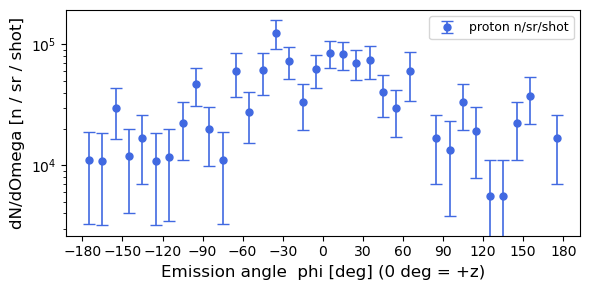

  Angular distribution peak:
    phi = -35 deg   yield = 1.248e+05 n/sr/shot

[deuteron]
  Detected simulated primaries in PHITS run: 1,000,000,000
  Scaling per-source -> per-shot factor = D_PER_SHOT = 1e+10
  Sanity check factor (per-shot / simulated) = 1.000e+01


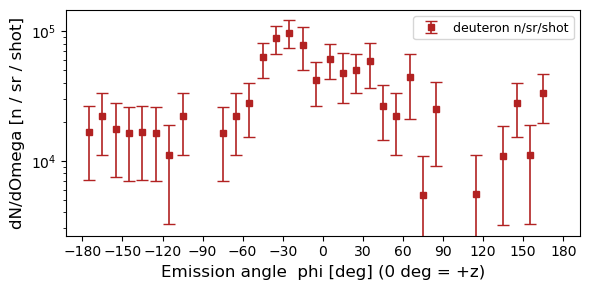

  Angular distribution peak:
    phi = -25 deg   yield = 9.804e+04 n/sr/shot


In [148]:
# Cell 2: Plot per-particle angular distributions and cache results for overlays
phi_plot = (phi_centers - 90.0)
phi_plot = ((phi_plot + 180.0) % 360.0) - 180.0
phi_plot = -phi_plot

PLOT_RESULTS = {}


for particle, data in DATASETS.items():
    out_file = data['OUT_FILE']
    out_dir = data['OUT_DIR']
    shots_per_shot = ANALYSIS_CONFIG['SHOTS_PER_DATASET'].get(particle, 1.0)
    beam_symbol = ANALYSIS_CONFIG['PARTICLE_SYMBOL'].get(particle, '?')

    simulated_sources = None
    phits_candidates = [
        os.path.join(os.path.dirname(out_file), 'phits.out') if out_file else '',
        os.path.join(out_dir, 'phits.out'),
        f'../output_{particle}/phits.out',
        f'output_{particle}/phits.out',
    ]

    for phits_path in phits_candidates:
        if phits_path and os.path.isfile(phits_path):
            with open(phits_path) as fh:
                lines = fh.read().splitlines()
            for i, line in enumerate(lines):
                if 'total source' in line:
                    for j in range(i + 1, min(i + 6, len(lines))):
                        toks = lines[j].strip().split()
                        if toks:
                            try:
                                simulated_sources = float(toks[-1])
                                break
                            except Exception:
                                continue
                    break
            if simulated_sources is not None:
                break

    print(f"\n[{particle}]")
    if simulated_sources is None:
        print('  PHITS simulated-source count not found in log - assuming outputs are normalized per source.')
    else:
        print(f'  Detected simulated primaries in PHITS run: {int(simulated_sources):,}')

    print(f'  Scaling per-source -> per-shot factor = {beam_symbol.upper()}_PER_SHOT = {shots_per_shot:.0e}')
    if simulated_sources:
        print(f'  Sanity check factor (per-shot / simulated) = {shots_per_shot / simulated_sources:.3e}')

    de = np.diff(data['E_EDGES'])
    total_yield = (data['spectra'] * de[np.newaxis, :]).sum(axis=1) * shots_per_shot
    total_err = np.sqrt(((data['errors'] * de[np.newaxis, :])**2).sum(axis=1)) * shots_per_shot

    fig, ax = plt.subplots(figsize=(6, 3))
    plot_color = ANALYSIS_CONFIG['PARTICLE_COLORS'].get(particle, 'steelblue')
    marker_style = 'o' if particle == 'proton' else 's'
    ax.errorbar(
        phi_plot,
        total_yield,
        yerr=total_err,
        fmt=marker_style,
        color=plot_color,
        ecolor=plot_color,
        capsize=4,
        markersize=5,
        lw=1.2,
        label=f'{particle} n/sr/shot',
    )
    ax.set_xlabel('Emission angle  phi [deg] (0 deg = +z)', fontsize=12)
    ax.set_ylabel('dN/dOmega [n / sr / shot]', fontsize=12)
    ax.set_xticks(ANALYSIS_CONFIG['XTICKS_DEG'])
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    peak_ip = np.argmax(total_yield)
    print('  Angular distribution peak:')
    print(f"    phi = {phi_plot[peak_ip]:+.0f} deg   yield = {total_yield[peak_ip]:.3e} n/sr/shot")

    PLOT_RESULTS[particle] = {
        'phi_plot': phi_plot.copy(),
        'total_yield': total_yield,
        'total_err': total_err,
        'OUT_DIR': out_dir,
        'SHOTS_PER_SHOT': shots_per_shot,
    }






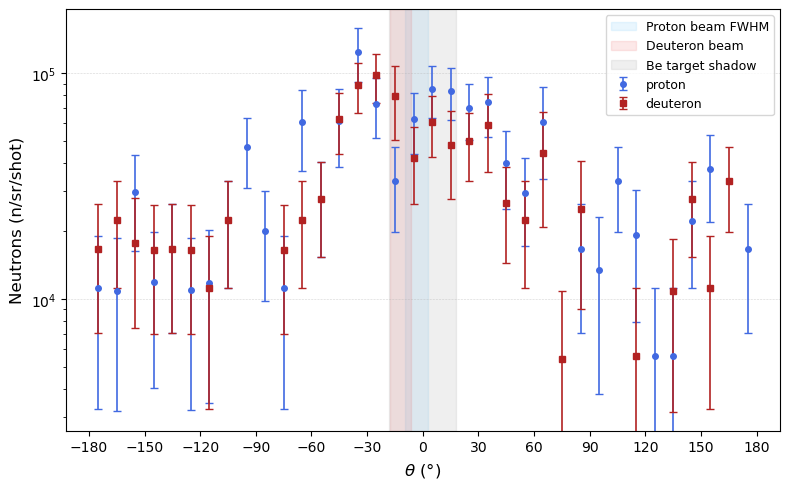

Saved proton/deuteron comparison plot: angular_comparison.pdf


In [147]:
# Cell 3: Compare proton vs deuteron angular distributions with beam-FWHM and target-shadow bands
if 'proton' in PLOT_RESULTS and 'deuteron' in PLOT_RESULTS:
    p = PLOT_RESULTS['proton']
    d = PLOT_RESULTS['deuteron']

    fig, ax = plt.subplots(figsize=(8, 5))
    proton_color = ANALYSIS_CONFIG['PARTICLE_COLORS']['proton']
    deuteron_color = ANALYSIS_CONFIG['PARTICLE_COLORS']['deuteron']

    ax.errorbar(
        p['phi_plot'],
        p['total_yield'],
        yerr=p['total_err'],
        fmt='o',
        color=proton_color,
        ecolor=proton_color,
        capsize=3,
        markersize=4,
        lw=1.2,
        label='proton',
    )
    ax.errorbar(
        d['phi_plot'],
        d['total_yield'],
        yerr=d['total_err'],
        fmt='s',
        color=deuteron_color,
        ecolor=deuteron_color,
        capsize=3,
        markersize=4,
        lw=1.2,
        label='deuteron',
    )

    proton_pointing_deg = ANALYSIS_CONFIG['BEAM_POINTING_DEG']['proton']
    deuteron_pointing_deg = ANALYSIS_CONFIG['BEAM_POINTING_DEG']['deuteron']
    proton_fwhm_deg = ANALYSIS_CONFIG['BEAM_FWHM_DEG']['proton']
    deuteron_fwhm_deg = ANALYSIS_CONFIG['BEAM_FWHM_DEG']['deuteron']
    shadow_lo_deg, shadow_hi_deg = ANALYSIS_CONFIG['BE_TARGET_SHADOW_DEG']

    ax.axvspan(
        proton_pointing_deg - 0.5 * proton_fwhm_deg,
        proton_pointing_deg + 0.5 * proton_fwhm_deg,
        color='lightskyblue',
        alpha=0.18,
        label=f'Proton beam FWHM',
    )
    ax.axvspan(
        deuteron_pointing_deg - 0.5 * deuteron_fwhm_deg,
        deuteron_pointing_deg + 0.5 * deuteron_fwhm_deg,
        color='lightcoral',
        alpha=0.18,
        label=f'Deuteron beam',
    )
    ax.axvspan(
        shadow_lo_deg,
        shadow_hi_deg,
        color='gray',
        alpha=0.12,
        label=f'Be target shadow',
    )

    ax.set_xlabel(r'$\theta$ ($\degree$)', fontsize=12)
    ax.set_ylabel(r'Neutrons (n/sr/shot)', fontsize=12)
    ax.set_xticks(ANALYSIS_CONFIG['XTICKS_DEG'])
    ax.set_yscale('log')
    ax.grid(axis='y', ls=':', lw=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()

    compare_out_dir = p['OUT_DIR']

    plt.savefig('angular_comparison.pdf')

    plt.show()
    print('Saved proton/deuteron comparison plot: angular_comparison.pdf')





Total detector angular coverage: 360.0 deg (6.2832 rad)


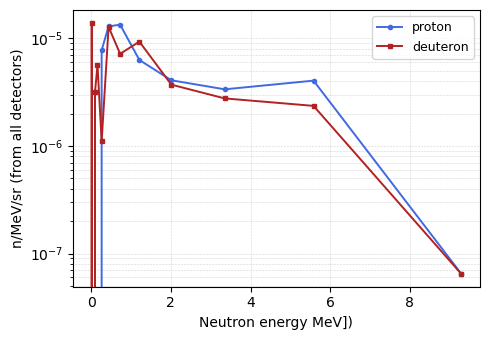

In [165]:
# Cell 4: Plot aggregated neutron energy spectrum normalized to n/MeV/sr
if not DATASETS:
    raise RuntimeError('DATASETS is empty. Run Cell 1 first.')

# Build detector-angle bin widths from phi centers (supports non-uniform spacing)
phi_sorted = np.sort(phi_centers)
phi_edges = np.empty(phi_sorted.size + 1, dtype=float)
phi_edges[1:-1] = 0.5 * (phi_sorted[:-1] + phi_sorted[1:])
phi_edges[0] = phi_sorted[0] - 0.5 * (phi_sorted[1] - phi_sorted[0])
phi_edges[-1] = phi_sorted[-1] + 0.5 * (phi_sorted[-1] - phi_sorted[-2])

# Wrap to get total contiguous angular coverage in detector plane
bin_widths_deg = np.diff(phi_edges)
bin_widths_rad = np.deg2rad(bin_widths_deg)
total_coverage_deg = bin_widths_deg.sum()
total_coverage_rad = bin_widths_rad.sum()

print(f'Total detector angular coverage: {total_coverage_deg:.1f} deg ({total_coverage_rad:.4f} rad)')

fig, ax = plt.subplots(figsize=(5, 3.5))

for particle, data in DATASETS.items():
    e_edges = data['E_EDGES']
    e_centers = np.sqrt(e_edges[:-1] * e_edges[1:])

    # spectra units per detector bin: n / (sr MeV source)
    # integrate over covered angle, then normalize by total covered angle
    spectrum_integrated = np.sum(data['spectra'] * bin_widths_rad[:, np.newaxis], axis=0)
    spectrum_n_per_MeV_sr = spectrum_integrated / total_coverage_rad

    color = ANALYSIS_CONFIG['PARTICLE_COLORS'].get(particle, 'black')
    marker = 'o' if particle == 'proton' else 's'
    ax.plot(
        e_centers,
        spectrum_n_per_MeV_sr*10,
        marker=marker,
        ms=3,
        lw=1.4,
        color=color,
        label=f'{particle}',
    )

ax.set_xscale('linear')
ax.set_yscale('log')
ax.set_xlabel('Neutron energy MeV])')
ax.set_ylabel('n/MeV/sr (from all detectors)')
ax.grid(True, which='both', ls=':', lw=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('energy_spectrum_comparison.pdf')
plt.show()



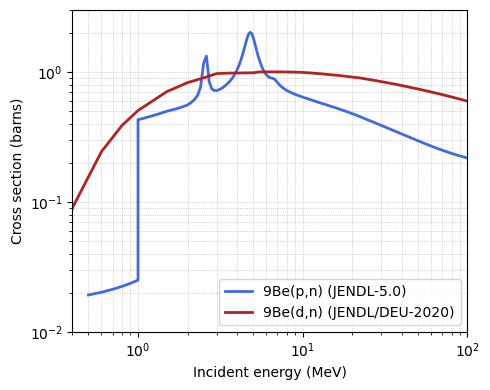

Loaded proton data from: jendl_pro_Be9.txt
Loaded deuteron data from: jendl_deu_Be9.txt
Points <= 100 MeV: proton=269, deuteron=58


In [166]:
# Cell 5: Parse JENDL MT=5 data and plot p,n vs d,n cross-section comparison

def parse_endf_value(s):
    """Convert ENDF-6 numeric field (11 chars) to float."""
    s = s.strip()
    if not s:
        return None

    # ENDF usually stores exponent without 'E', e.g. 1.234567+6
    if 'E' not in s and 'e' not in s:
        pos_plus = s.rfind('+')
        pos_minus = s.rfind('-')
        exp_pos = max(pos_plus, pos_minus)
        if exp_pos > 0:
            s = s[:exp_pos] + 'E' + s[exp_pos:]

    try:
        return float(s)
    except ValueError:
        return None


def get_mt5_cross_section(filepath):
    """Parse ENDF MF=3, MT=5 TAB1 and return (energy_MeV, sigma_barns)."""
    values = []

    with open(filepath, 'r') as f:
        for line in f:
            if len(line) < 75:
                continue

            try:
                mf = int(line[70:72])
                mt = int(line[72:75])
            except ValueError:
                continue

            if mf == 3 and mt == 5:
                for i in range(6):
                    v = parse_endf_value(line[i * 11:(i + 1) * 11])
                    if v is not None:
                        values.append(v)

    if len(values) < 12:
        raise RuntimeError(f'Could not parse MF=3 MT=5 data from {filepath}')

    # ENDF TAB1 layout:
    # line 1: C1 C2 L1 L2 N1 N2
    # line 2: C1 C2 L1 L2 NR NP
    # line 3+: (NBT,INT) pairs (2*NR), then NP pairs (E, sigma)
    nr = int(round(values[10]))
    np_points = int(round(values[11]))

    header_len = 12 + 2 * nr
    needed = header_len + 2 * np_points
    if len(values) < needed:
        raise RuntimeError(
            f'Incomplete MF=3 MT=5 TAB1 in {filepath}: '
            f'NR={nr}, NP={np_points}, values={len(values)}, needed={needed}'
        )

    points = values[header_len:header_len + 2 * np_points]
    energy_eV = points[0::2]
    sigma = points[1::2]

    energy_MeV = [e / 1e6 for e in energy_eV]
    return energy_MeV, sigma


pro_file = first_existing(ANALYSIS_CONFIG['JENDL_CANDIDATES']['proton'])
deu_file = first_existing(ANALYSIS_CONFIG['JENDL_CANDIDATES']['deuteron'])

if pro_file is None or deu_file is None:
    raise FileNotFoundError(
        f'Missing files. proton={pro_file}, deuteron={deu_file}. '
        'Expected jendl_pro_Be9.txt and jendl_deu_Be9.txt in analysis/.'
    )

E_pro, XS_pro = get_mt5_cross_section(pro_file)
E_deu, XS_deu = get_mt5_cross_section(deu_file)

# Keep only positive values up to configured max energy
max_energy_mev = ANALYSIS_CONFIG['XS_MAX_ENERGY_MEV']
pro = [(e, s) for e, s in zip(E_pro, XS_pro) if e > 0 and s > 0 and e <= max_energy_mev]
deu = [(e, s) for e, s in zip(E_deu, XS_deu) if e > 0 and s > 0 and e <= max_energy_mev]

if not pro or not deu:
    raise RuntimeError(f'No positive MT=5 points found up to {max_energy_mev} MeV for one or both datasets.')

E_pro_plot, XS_pro_plot = zip(*pro)
E_deu_plot, XS_deu_plot = zip(*deu)

plt.figure(figsize=(5, 4))
plt.plot(E_pro_plot, XS_pro_plot, lw=2, color='royalblue', label='9Be(p,n) (JENDL-5.0)')
plt.plot(E_deu_plot, XS_deu_plot, lw=2, color='firebrick', label='9Be(d,n) (JENDL/DEU-2020)')

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.4, max_energy_mev)
plt.ylim(1e-2, 3e0)
plt.xlabel('Incident energy (MeV)')
plt.ylabel('Cross section (barns)')
plt.grid(True, which='both', ls=':', lw=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('jendl_cross_section_comparison.pdf')
plt.show()

print(f'Loaded proton data from: {pro_file}')
print(f'Loaded deuteron data from: {deu_file}')
print(f'Points <= {max_energy_mev:.0f} MeV: proton={len(E_pro_plot)}, deuteron={len(E_deu_plot)}')



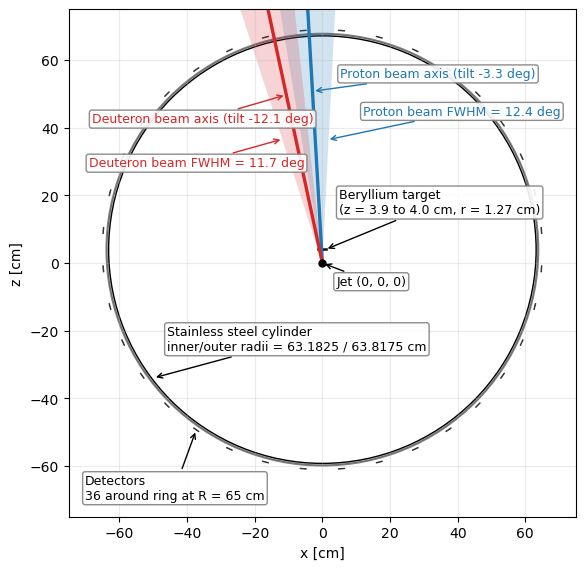

In [167]:
# Cell 6: Draw top-down PHITS geometry with cylinder, detector rectangles, target, and beam cones
from matplotlib.patches import Circle, Polygon, Rectangle

cyl = GEOMETRY_CONFIG['CYLINDER']
be = GEOMETRY_CONFIG['BE_TARGET']
det = GEOMETRY_CONFIG['DETECTORS']
beam_len = GEOMETRY_CONFIG['BEAM_DRAW_LEN_CM']
phi_deg = phi_centers.copy()

beam_draw = {
    'proton': {
        'label': 'Proton beam',
        'tilt_deg': GEOMETRY_CONFIG['BEAM_TILT_TOPDOWN_DEG']['proton'],
        'fwhm_deg': ANALYSIS_CONFIG['BEAM_FWHM_DEG']['proton'],
        'color': '#1f77b4',
        'alpha': 0.20,
    },
    'deuteron': {
        'label': 'Deuteron beam',
        'tilt_deg': GEOMETRY_CONFIG['BEAM_TILT_TOPDOWN_DEG']['deuteron'],
        'fwhm_deg': ANALYSIS_CONFIG['BEAM_FWHM_DEG']['deuteron'],
        'color': '#d62728',
        'alpha': 0.20,
    },
}

fig, ax = plt.subplots(figsize=(6, 6))

# Stainless steel cylinder shell
outer = Circle((cyl['center_x_cm'], cyl['center_z_cm']), cyl['r_outer_cm'],
               facecolor='#b0b0b0', edgecolor='black', lw=1.5, alpha=0.50)
inner = Circle((cyl['center_x_cm'], cyl['center_z_cm']), cyl['r_inner_cm'],
               facecolor='white', edgecolor='black', lw=1.0)
ax.add_patch(outer)
ax.add_patch(inner)

# Detector rectangles around ring
for phi in phi_deg:
    pr = np.deg2rad(phi)
    ur = np.array([np.cos(pr), np.sin(pr)]) * det['dr_cm']
    vt = np.array([-np.sin(pr), np.cos(pr)]) * det['width_tangential_cm']

    center = np.array([det['radius_cm'] * np.cos(pr), cyl['center_z_cm'] + det['radius_cm'] * np.sin(pr)])
    origin = center - 0.5 * ur - 0.5 * vt
    corners = np.array([origin, origin + ur, origin + ur + vt, origin + vt])

    ax.add_patch(Polygon(corners, closed=True, facecolor='none', edgecolor='#222222', lw=0.6, alpha=0.9))

# Be target slab projection and center-hole guide
be_rect = Rectangle((-be['r_outer_cm'], be['z_min_cm']),
                    2 * be['r_outer_cm'],
                    be['z_max_cm'] - be['z_min_cm'],
                    facecolor='#2ca02c', edgecolor='black', lw=1.2, alpha=0.85)
hole_guide = Rectangle((-be['r_inner_cm'], be['z_min_cm']),
                       2 * be['r_inner_cm'],
                       be['z_max_cm'] - be['z_min_cm'],
                       facecolor='none', edgecolor='black', lw=0.8, linestyle='--', hatch='///')
ax.add_patch(be_rect)
ax.add_patch(hole_guide)

# Beam centerlines and FWHM wedges
start = np.array([0.0, 0.0])
beam_points = {}

for particle, b in beam_draw.items():
    tilt = np.deg2rad(b['tilt_deg'])
    fwhm_half = np.deg2rad(b['fwhm_deg'] / 2.0)
    axis_ang = np.pi / 2 + tilt

    def point_at(angle):
        return start + beam_len * np.array([np.cos(angle), np.sin(angle)])

    p_axis = point_at(axis_ang)
    p_lo = point_at(axis_ang - fwhm_half)
    p_hi = point_at(axis_ang + fwhm_half)

    ax.add_patch(Polygon(np.vstack([start, p_lo, p_hi]), closed=True,
                         facecolor=b['color'], edgecolor='none', alpha=b['alpha']))
    ax.plot([start[0], p_axis[0]], [start[1], p_axis[1]], color=b['color'], lw=2.4)

    beam_points[particle] = {
        'axis': p_axis,
        'lo': p_lo,
        'hi': p_hi,
        'tilt_deg': b['tilt_deg'],
        'fwhm_deg': b['fwhm_deg'],
        'color': b['color'],
        'label': b['label'],
    }

# Arrow labels
label_box = dict(boxstyle='round,pad=0.2', fc='white', ec='0.5', alpha=0.9)
arrow = dict(arrowstyle='->', lw=1.0)

ax.scatter([0], [0], color='black', s=25, zorder=6)
ax.annotate('Jet (0, 0, 0)', xy=(0, 0), xytext=(10, -16), textcoords='offset points',
            fontsize=9, bbox=label_box, arrowprops=arrow)
ax.annotate('Stainless steel cylinder\ninner/outer radii = 63.1825 / 63.8175 cm',
            xy=(-50, -34), xytext=(10, 20), textcoords='offset points',
            fontsize=9, bbox=label_box, arrowprops=arrow)

sample_phi = np.deg2rad(235)
sample_det = (det['radius_cm'] * np.cos(sample_phi), cyl['center_z_cm'] + det['radius_cm'] * np.sin(sample_phi))
ax.annotate('Detectors\n36 around ring at R = 65 cm',
            xy=sample_det, xytext=(-80, -50), textcoords='offset points',
            fontsize=9, bbox=label_box, arrowprops=arrow)

ax.annotate('Beryllium target\n(z = 3.9 to 4.0 cm, r = 1.27 cm)',
            xy=(0.8, 3.95), xytext=(10, 26), textcoords='offset points',
            fontsize=9, bbox=label_box, arrowprops=arrow)

for particle, pts in beam_points.items():
    xy_axis = (0.62 * pts['axis'][0], 0.62 * pts['axis'][1])
    if particle == 'proton':
        axis_text_offset = (20, 10)
        fwhm_target = (-0.1 * pts['hi'][0], 0.45 * pts['hi'][1])
        fwhm_text_offset = (26, 18)
    else:
        axis_text_offset = (-140, -20)
        fwhm_target = (1.3 * pts['lo'][0], 0.45 * pts['lo'][1])
        fwhm_text_offset = (-140, -20)

    ax.annotate(
        f"{pts['label']} axis (tilt -{pts['tilt_deg']:.1f} deg)",
        xy=xy_axis,
        xytext=axis_text_offset,
        textcoords='offset points',
        fontsize=9,
        color=pts['color'],
        bbox=label_box,
        arrowprops={**arrow, 'color': pts['color']},
    )
    ax.annotate(
        f"{pts['label']} FWHM = {pts['fwhm_deg']:.1f} deg",
        xy=fwhm_target,
        xytext=fwhm_text_offset,
        textcoords='offset points',
        fontsize=9,
        color=pts['color'],
        bbox=label_box,
        arrowprops={**arrow, 'color': pts['color']},
    )

ax.set_xlabel('x [cm]')
ax.set_ylabel('z [cm]')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('geometry_top_down_view.pdf')
plt.show()




In [ ]:
# Cell 7: Planning notes for additional simulations and comparisons
# Simulate 9Be(p,n) to see if we have the same offset as with 9Be(d,n)
# Simulate without the converter, with detector area 19 mm x 40 mm
# Build table: total neutrons with and without converter vs experiment
# Compare converter-on flux using both proton and deuteron cases
# Compare neutron spectra for each scenario

